In [1]:
import pandas as pd
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
df = pd.read_csv("../data/processed/preprocessed_news.csv")

print(df.shape)
print(df["label"].value_counts())

(39105, 2)
label
1    21197
0    17908
Name: count, dtype: int64


In [3]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print(train_df.shape)
print(test_df.shape)

(31284, 2)
(7821, 2)


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = "../models/best_model"

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_PATH)

model = DistilBertForSequenceClassification.from_pretrained(MODEL_PATH)

model.to(device)
model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

In [5]:
y_true = []
y_pred = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):

    text = row["content"]

    encoding = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

    prediction = torch.argmax(outputs.logits, dim=1).item()

    y_true.append(row["label"])
    y_pred.append(prediction)

  0%|          | 0/7821 [00:00<?, ?it/s]

In [6]:
accuracy = accuracy_score(y_true, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9997


In [7]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Fake", "Real"]
    )
)

              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      3582
        Real       1.00      1.00      1.00      4239

    accuracy                           1.00      7821
   macro avg       1.00      1.00      1.00      7821
weighted avg       1.00      1.00      1.00      7821



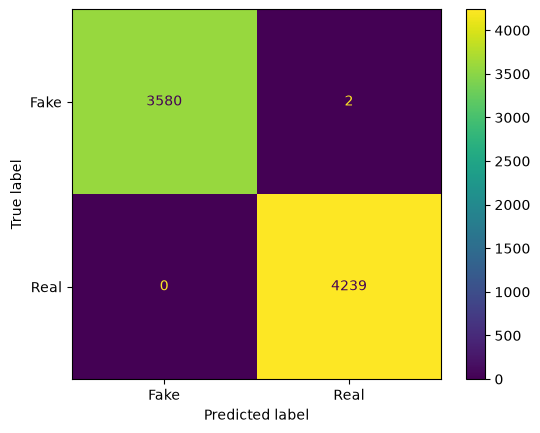

In [8]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake","Real"]
)

disp.plot()

plt.show()

In [1]:
import os

print(os.listdir("../models/best_model"))

['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']
